In [40]:
import pandas as pd
from pandas.plotting import parallel_coordinates
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')

# Load all the necessary data
df_players = pd.read_json("Data/players.json")
df_teams = pd.read_json("Data/teams.json")
df_ranks = pd.read_json("Data/playerank.json")

In [3]:
paths = [
    'Data/events/events_France.json',
    'Data/events/events_Germany.json',
    'Data/events/events_Italy.json',
    'Data/events/events_Spain.json',
    "Data/events/events_England.json"
]

df_events = pd.concat(
    [pd.read_json(p) for p in paths],
    ignore_index=True
)
df_events

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id
0,8,Simple pass,[{'id': 1801}],253784,"[{'y': 51, 'x': 50}, {'y': 46, 'x': 31}]",2500686,Pass,3799,1H,1.935181,85,176505119
1,8,High pass,[{'id': 1801}],29474,"[{'y': 46, 'x': 31}, {'y': 74, 'x': 68}]",2500686,Pass,3799,1H,3.599295,83,176505121
2,1,Air duel,"[{'id': 703}, {'id': 1801}]",253784,"[{'y': 74, 'x': 68}, {'y': 54, 'x': 72}]",2500686,Duel,3799,1H,6.827043,10,176505122
3,1,Air duel,"[{'id': 701}, {'id': 1802}]",56441,"[{'y': 26, 'x': 32}, {'y': 46, 'x': 28}]",2500686,Duel,3772,1H,6.985577,10,176505017
4,1,Ground attacking duel,"[{'id': 702}, {'id': 1801}]",366760,"[{'y': 54, 'x': 72}, {'y': 55, 'x': 73}]",2500686,Duel,3799,1H,9.511272,11,176505124
...,...,...,...,...,...,...,...,...,...,...,...,...
3071390,5,Ball out of the field,[],0,"[{'y': 32, 'x': 0}, {'y': 100, 'x': 100}]",2500098,Interruption,1623,2H,2796.732525,50,251596409
3071391,3,Corner,"[{'id': 302}, {'id': 801}, {'id': 1801}]",70965,"[{'y': 100, 'x': 100}, {'y': 47, 'x': 88}]",2500098,Free Kick,1633,2H,2829.821084,30,251596232
3071392,1,Air duel,"[{'id': 701}, {'id': 1802}]",7919,"[{'y': 53, 'x': 12}, {'y': 50, 'x': 14}]",2500098,Duel,1623,2H,2831.211419,10,251596410
3071393,1,Air duel,"[{'id': 703}, {'id': 1801}]",8005,"[{'y': 47, 'x': 88}, {'y': 50, 'x': 86}]",2500098,Duel,1633,2H,2832.434399,10,251596234


In [4]:
def won_duels(tags):
    if not isinstance(tags, list):
        return False
    return any(tag['id'] == 703 for tag in tags)

def prevented_pass(tags):
    if not isinstance(tags, list):
        return False
    return any(tag['id'] in [1401, 2101] for tag in tags)   #1401 interception. 2101 blocked

def blocked_shots(tags):
    if not isinstance(tags, list):
        return False
    return any(tag['id'] == 2101 for tag in tags)

In [5]:
# All defenders id's
defenders = df_players[df_players['role'].apply(lambda t: t['name'] == 'Defender')]['wyId'].tolist()

# All duels
duels = df_events[df_events['eventId'] == 1]

# Duels and events for defenders
duels_def = duels[duels["playerId"].isin(defenders)].copy()
events_def = df_events[df_events['playerId'].isin(defenders)].copy()
df_defenders = df_players[df_players['wyId'].isin(defenders)].copy()

# All defended shots
shots = df_events[
    (df_events["eventId"] == 10) &
    (df_events["playerId"].isin(defenders))
].copy()

# All players playtime
ranks_def = df_ranks[["playerId", "minutesPlayed"]].copy()
ranks_def = ranks_def[ranks_def["playerId"].isin(defenders)]
player_minutes = ranks_def.groupby("playerId", as_index=False)["minutesPlayed"].sum()

# All duels defenders won
duels_def['won'] = duels_def['tags'].apply(won_duels)

# Some key tags
total_duels = len(duels_def)
total_won_duels = int(duels_def['won'].sum())
passes_prevented = int(events_def['tags'].apply(prevented_pass).sum())
shots_blocked = (shots['tags'].apply(blocked_shots).sum())

In [6]:
# Sorting all dataframes
duels_per_player = (
    duels_def.groupby("playerId")["won"]
    .agg(total_duels="count", won_duels="sum")
    .reset_index()
)

prevented_per_player = (
    events_def.assign(prevented=events_def["tags"].apply(prevented_pass))
    .groupby("playerId")["prevented"].sum()
    .reset_index()
    .rename(columns={"prevented": "passes_prevented"})
)

blocked_shots_per_player = (
    shots.assign(blocked=shots["tags"].apply(blocked_shots))
    .groupby("playerId")["blocked"]
    .sum()
    .reset_index()
    .rename(columns={"blocked": "blocked_shots"})
)

# Merging all dataframes
player_stats = (
    pd.DataFrame({
        'playerId' : defenders
    })
    .merge(duels_per_player, on="playerId", how='left')
    .merge(prevented_per_player, on="playerId", how='left')
    .merge(blocked_shots_per_player, on="playerId", how='left')
    .merge(player_minutes, on="playerId", how='left')
    .dropna(axis=0, how='any')
)

# Keeping the defenders that has played more than 1000 minutes to keep the datasets clean for the per 90 metrics
player_stats = player_stats[player_stats['minutesPlayed'] > 1600]

player_stats['total_duels_per_90'] = (
    player_stats['total_duels'] / player_stats['minutesPlayed'] * 90
)
player_stats['winrate_per_duels'] = (
    (player_stats['won_duels']/player_stats['total_duels'])
)
player_stats['prevented_per_90'] = (
    player_stats['passes_prevented'] / player_stats['minutesPlayed'] * 90
)
player_stats['blocked_per_90'] = (
    player_stats['blocked_shots'] / player_stats['minutesPlayed'] * 90
)

# print(player_stats.head(5))
player_stats

,playerId,total_duels,won_duels,passes_prevented,blocked_shots,minutesPlayed,total_duels_per_90,winrate_per_duels,prevented_per_90,blocked_per_90
2,36,182.0,66.0,55.0,1.0,2160.0,7.583333,0.362637,2.291667,0.041667
3,48,602.0,315.0,226.0,12.0,4104.0,13.201754,0.523256,4.956140,0.263158
4,229427,538.0,249.0,173.0,3.0,2520.0,19.214286,0.462825,6.178571,0.107143
5,393284,568.0,194.0,229.0,3.0,2998.0,17.051368,0.341549,6.874583,0.090060
6,77,338.0,147.0,168.0,4.0,2250.0,13.520000,0.434911,6.720000,0.160000
...,...,...,...,...,...,...,...,...,...,...
1111,28528,399.0,132.0,136.0,1.0,2419.0,14.844977,0.330827,5.059942,0.037205
1115,28335,603.0,218.0,149.0,1.0,2457.0,22.087912,0.361526,5.457875,0.036630
1120,228963,500.0,204.0,205.0,3.0,2640.0,17.045455,0.408000,6.988636,0.102273
1126,290119,562.0,269.0,205.0,5.0,3104.0,16.295103,0.478648,5.943943,0.144974


In [7]:
df_ML = (
    player_stats
    .copy()
    .rename(columns={'playerId': 'wyId'})
)
df_ML = df_ML.merge(
    df_players[["wyId", "shortName", "currentTeamId"]],
    on="wyId",
    how="left"
)
team_map = (
    pd.DataFrame(df_teams)
    .assign(area=lambda x: x['area'].apply(lambda a: a.get('name') if isinstance(a, dict) else None))
    [['wyId', 'name', 'area']]
    .rename(columns={'wyId': 'teamId', 'name': 'team'})
)
league_map = {
    'England': 'Premier League',
    'Wales': 'Premier League',
    'Germany': 'Bundesliga',
    'France': 'Ligue 1',
    'Italy': 'Serie A',
    'Spain': 'La Liga',
    'Monaco': 'Ligue 1'
}
team_map['league'] = team_map['area'].map(league_map)
team_map['league'] = team_map['league'].fillna('Unsigned')
team_map = team_map.drop('area', axis=1)
df_ML = df_ML.merge(
    team_map,
    left_on="currentTeamId",
    right_on="teamId",
    how="left"
)

w_duels = 1
w_wr = 5
w_prev = 1
w_blocked = 1

df_ML['def_index'] = (
    (df_ML['total_duels_per_90'] * w_duels) +
    (df_ML['winrate_per_duels'] * w_wr) +
    (df_ML['prevented_per_90'] * w_prev) +
    (df_ML['blocked_per_90'] * w_blocked)
)

df_ML

,wyId,total_duels,won_duels,passes_prevented,blocked_shots,minutesPlayed,total_duels_per_90,winrate_per_duels,prevented_per_90,blocked_per_90,shortName,currentTeamId,teamId,team,league,def_index
0,36,182.0,66.0,55.0,1.0,2160.0,7.583333,0.362637,2.291667,0.041667,T. Alderweireld,1624,1624.0,Tottenham Hotspur,Premier League,11.729853
1,48,602.0,315.0,226.0,12.0,4104.0,13.201754,0.523256,4.956140,0.263158,J. Vertonghen,1624,1624.0,Tottenham Hotspur,Premier League,21.037332
2,229427,538.0,249.0,173.0,3.0,2520.0,19.214286,0.462825,6.178571,0.107143,A. Djiku,3783,3783.0,Caen,Ligue 1,27.814126
3,393284,568.0,194.0,229.0,3.0,2998.0,17.051368,0.341549,6.874583,0.090060,C. Traor\u00e9,3795,3795.0,Troyes,Ligue 1,25.723757
4,77,338.0,147.0,168.0,4.0,2250.0,13.520000,0.434911,6.720000,0.160000,N. Moisander,2443,2443.0,Werder Bremen,Bundesliga,22.574556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,28528,399.0,132.0,136.0,1.0,2419.0,14.844977,0.330827,5.059942,0.037205,J. Ikoko,3785,3785.0,Guingamp,Ligue 1,21.596260
428,28335,603.0,218.0,149.0,1.0,2457.0,22.087912,0.361526,5.457875,0.036630,R. Aguilar,3787,3787.0,Montpellier,Ligue 1,29.390046
429,228963,500.0,204.0,205.0,3.0,2640.0,17.045455,0.408000,6.988636,0.102273,H. Traor\u00e9,3774,3774.0,Rennes,Ligue 1,26.176364
430,290119,562.0,269.0,205.0,5.0,3104.0,16.295103,0.478648,5.943943,0.144974,M. Niakhat\u00e9,2460,2460.0,Mainz 05,Bundesliga,24.777259


In [33]:
# Example: your features and target
feat_col = [
    'total_duels_per_90',
    'winrate_per_duels',
    'prevented_per_90',
    'blocked_per_90'
]
target = 'def_index'

df_ML_PL = df_ML[df_ML['league'] == 'Premier League'].copy()
df_ML_eur = df_ML[df_ML['league'] != 'Premier League'].copy()

X = df_ML_PL[feat_col].values  # convert to numpy array
y = df_ML_PL[target].values.reshape(-1, 1)  # make it (n_samples,1)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=250202
)

# Scale features (important for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Define the regression model
class reg_model(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

model = reg_model()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

epochs = 200
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")
        y_pred = model(X_test)
        test_loss = criterion(y_pred, y_test)
        rmse = test_loss.item()**0.5
        print(f"Test RMSE: {rmse:.4f}")


model.eval()
with torch.no_grad():
    X_all = scaler.transform(df_ML_eur[feat_col].values)  # scale
    X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
    df_ML_eur['predicted_def_index'] = model(X_all_tensor).numpy()

out = pd.DataFrame({
    'wyId': df_ML_eur['wyId'],
    'Short Name': df_ML_eur['shortName'],
    'team': df_ML_eur['team'],
    'league': df_ML_eur['league'],
    'predicted_def_index': df_ML_eur['predicted_def_index']
})

top_25_list = (
    out.sort_values('predicted_def_index', ascending=False)
       .head(25)
       .reset_index(drop=True)
)

top_25_list

Epoch [50/200], Loss: 3.0058
Test RMSE: 1.7671
Epoch [100/200], Loss: 0.0953
Test RMSE: 0.5152
Epoch [150/200], Loss: 0.0294
Test RMSE: 0.4248
Epoch [200/200], Loss: 0.0163
Test RMSE: 0.3846


,wyId,Short Name,team,league,predicted_def_index
0,343685,William,Wolfsburg,Bundesliga,38.475227
1,131184,Ali Adnan,Udinese,Serie A,35.193756
2,272434,W. Anton,Hannover 96,Bundesliga,34.484959
3,28908,F. Guilbert,Caen,Ligue 1,33.343575
4,144867,K. Malcuit,Lille,Ligue 1,32.983067
5,143566,Douglas Santos,Hamburger SV,Bundesliga,32.977875
6,393214,V. Rosier,Dijon,Ligue 1,32.956696
7,300784,Jorge,Monaco,Ligue 1,32.903629
8,14852,Sergio Escudero,Sevilla,La Liga,32.536469
9,263105,Pablo Maffeo,Girona,La Liga,32.493927


In [ ]:
# df_ML.loc[df_ML['wyId'] == 343685]

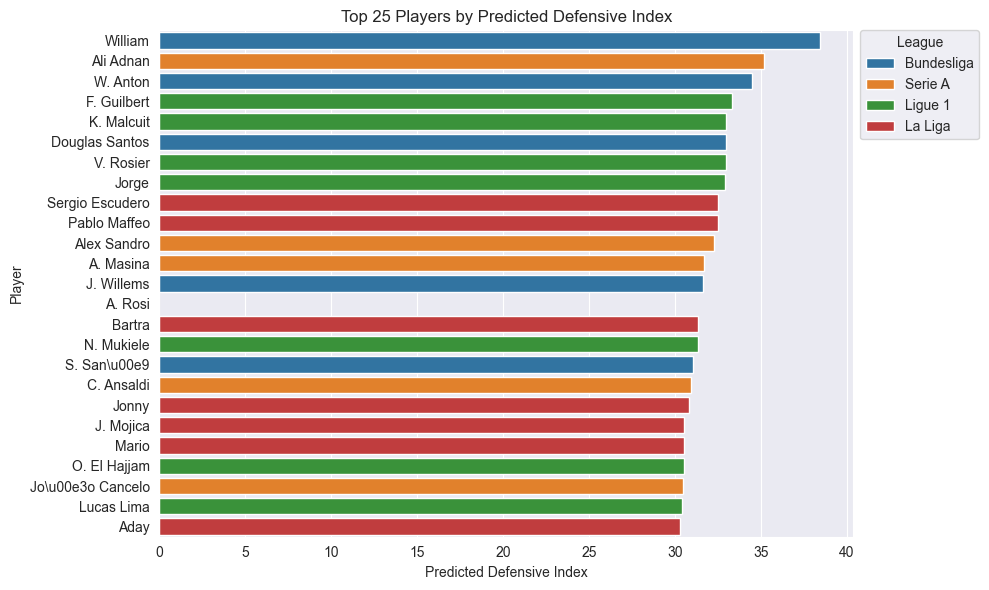

In [35]:
# Sort and take top 25 players
top25 = df_ML_eur.sort_values('predicted_def_index', ascending=False).head(25)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top25,
    x='predicted_def_index',
    y='shortName',
    hue='league',
    dodge=False,
    palette='tab10'
)

plt.title('Top 25 Players by Predicted Defensive Index')
plt.xlabel('Predicted Defensive Index')
plt.ylabel('Player')

plt.legend(
    title='League',
    bbox_to_anchor=(1.01, 1),   # x=1.05 means just outside right edge
    loc='upper left',
    borderaxespad=0.
)

plt.tight_layout()
plt.show()


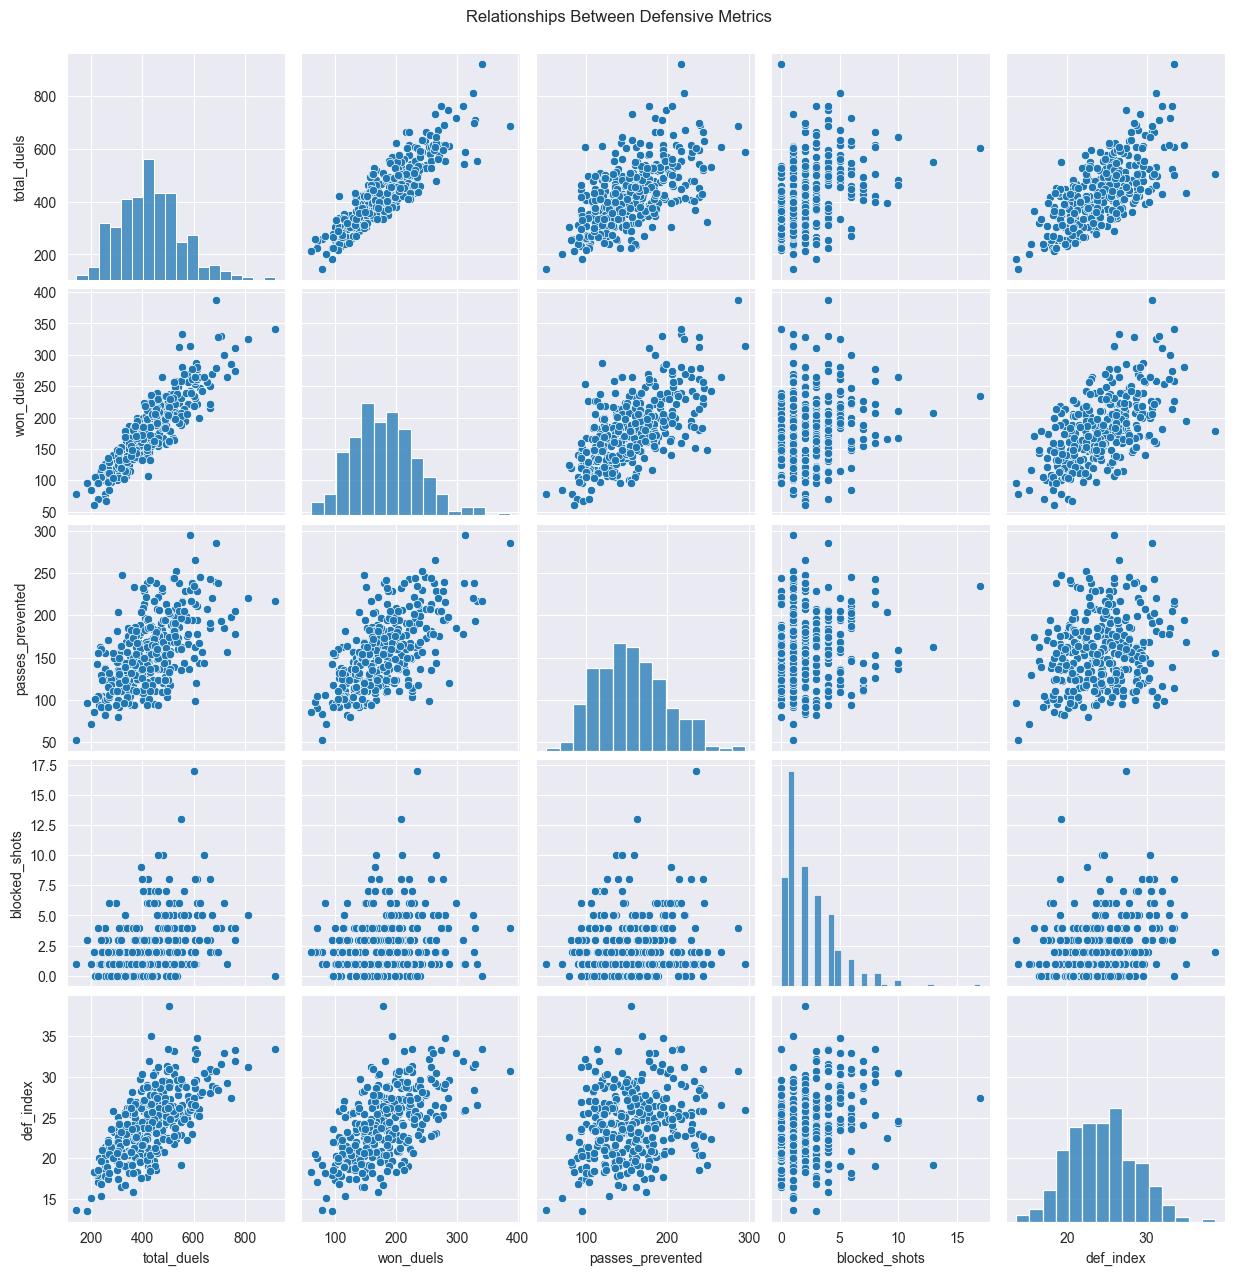

In [36]:
sns.pairplot(df_ML_eur, vars=['total_duels', 'won_duels', 'passes_prevented', 'blocked_shots', 'def_index'])
plt.suptitle("Relationships Between Defensive Metrics", y=1.02)
plt.show()

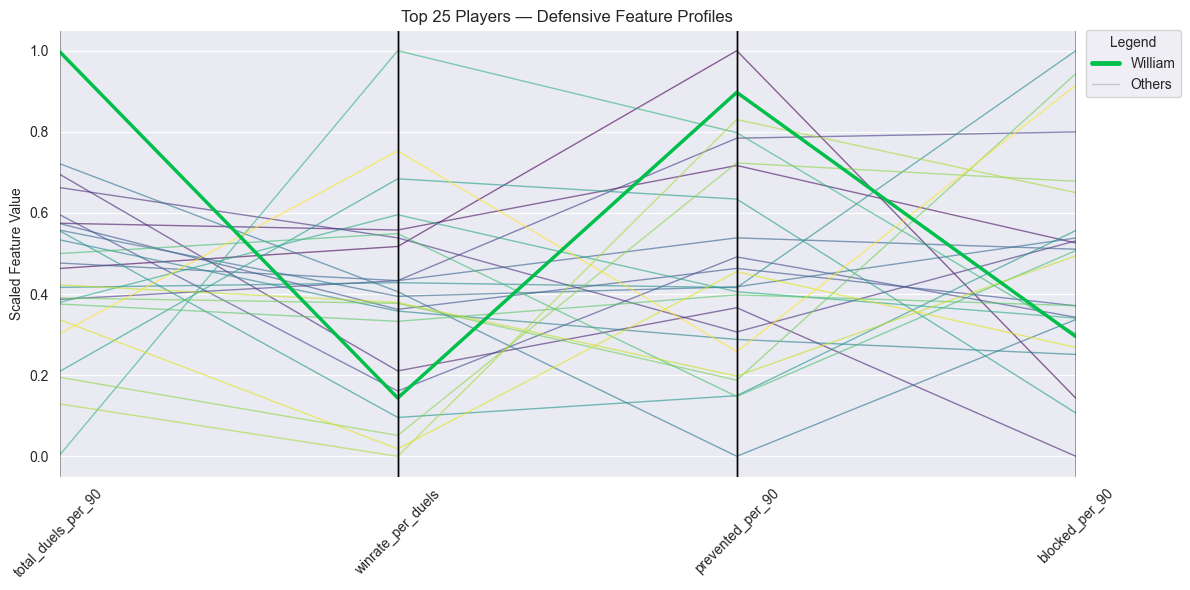

In [45]:
top25_scaled = top25.copy()
features = feat_col
scaler = MinMaxScaler()
top25_scaled[features] = scaler.fit_transform(top25_scaled[features])

highlight_name = top25_scaled.iloc[0]['shortName']

df_bg = top25_scaled[top25_scaled['shortName'] != highlight_name][['shortName'] + features]
df_hl = top25_scaled[top25_scaled['shortName'] == highlight_name][['shortName'] + features]

plt.figure(figsize=(12,6))
ax = plt.gca()

bg_colors = plt.cm.viridis(np.linspace(0, 1, len(df_bg)))
parallel_coordinates(df_bg, 'shortName', ax=ax, color=bg_colors, alpha=0.6, linewidth=1)

if ax.get_legend() is not None:
    ax.get_legend().remove()

parallel_coordinates(df_hl, 'shortName', ax=ax, color="#00c04b", linewidth=2.5, alpha=1)

proxy_others = Line2D([0], [0], color='gray', lw=1, alpha=0.35)
proxy_hl = Line2D([0], [0], color='#00c04b', lw=3.5, alpha=1)
ax.legend([proxy_hl, proxy_others], [highlight_name, 'Others'],
          title='Legend',
          bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)

plt.title('Top 25 Players — Defensive Feature Profiles')
plt.ylabel('Scaled Feature Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


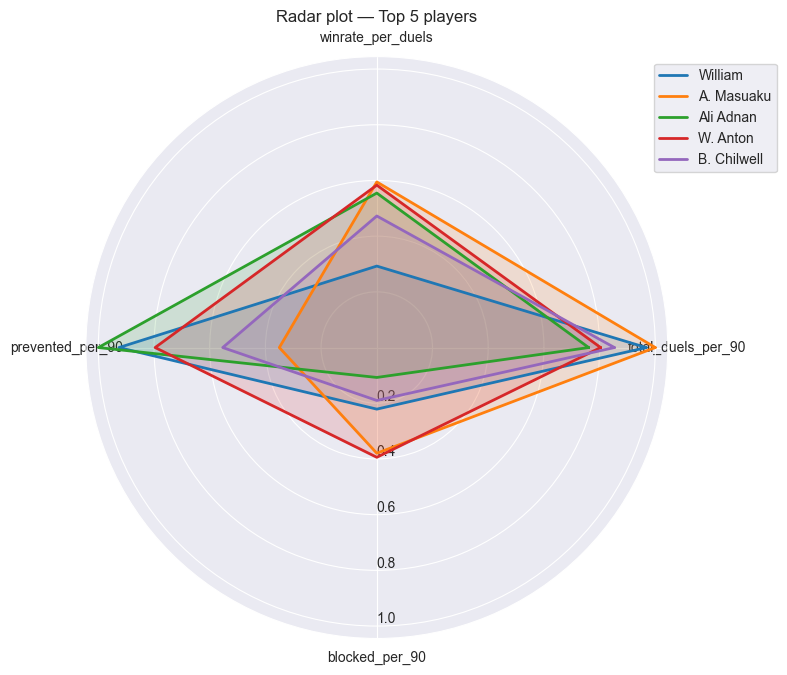

In [46]:
k = 5
topk = df_ML.sort_values('def_index', ascending=False).head(k).copy()

radar_features = features

scaler = MinMaxScaler()
df_scaled = df_ML.copy()
df_scaled[radar_features] = scaler.fit_transform(df_ML[radar_features].fillna(0))

topk_scaled = df_scaled.loc[topk.index, radar_features]

num_vars = len(radar_features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

def player_values(row):
    vals = row[radar_features].tolist()
    vals += vals[:1]
    return vals

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

colors = sns.color_palette('tab10', n_colors=k)
for i, (idx, row) in enumerate(topk_scaled.iterrows()):
    vals = player_values(row)
    ax.plot(angles, vals, label=f"{topk.loc[idx,'shortName']}", linewidth=2)
    ax.fill(angles, vals, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features)

ax.set_rlabel_position(-90)
ax.yaxis.grid(True)
ax.xaxis.grid(True)
plt.title(f"Radar plot — Top {k} players")
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()

# William de Asevedo Furtado